In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error


In [116]:
class MyLR:

    def __init__(self):
        self.coef_ = None
        self.intercept_ = None
    
    def fit(self, X_train, y_train):
        X_train = np.insert(X_train.to_numpy(), 0, 1, axis=1)

        betas = np.linalg.inv(np.dot(X_train.T, X_train)).dot(X_train.T).dot(y_train)

        self.intercept_ = betas[0]
        self.coef_ = betas[1:]
        
    def predict(self, X_test):
        
        return np.dot(X_test, self.coef_) + self.intercept_


In [ ]:
df = pd.read_csv('data/salary.csv')
df.head()

,Years_of_Experience,Salary
0,12.79,105700.72
1,4.46,52387.59
2,14.73,108689.74
3,1.74,25986.65
4,8.44,79090.86


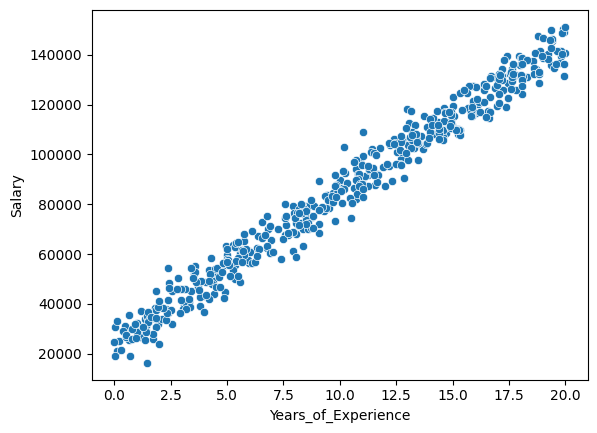

In [106]:
sns.scatterplot(x=df['Years_of_Experience'],y = df['Salary'], markers='X')
plt.show()

In [117]:
lr = MyLR()

In [118]:
X = df[['Years_of_Experience']]
y = df['Salary']

In [119]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

In [120]:
lr.fit(X_train, y_train)

In [122]:
lr.coef_, lr.intercept_

(array([6065.05473613]), np.float64(23901.082724015825))

In [124]:
pred = lr.predict(X_test)

mean_absolute_error(y_test, pred)

4135.30573025198

In [125]:
sklearnLR = LinearRegression()

sklearnLR.fit(X_train,y_train)

y_pred = sklearnLR.predict(X_test)

mean_absolute_error(y_pred , y_test)

4135.30573025198